In [8]:
# 1. Download your repository from GitHub
!git clone https://github.com/MRoberto25/fashion_mnist_pro.git

# 2. Move inside the downloaded folder
%cd fashion_mnist_pro

# 3. Check that the files are there
!ls

Cloning into 'fashion_mnist_pro'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 111 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 1.22 MiB | 12.36 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/fashion_mnist_pro/fashion_mnist_pro/fashion_mnist_pro
01_data_pipeline.py   data		       outputs
02_train_pipeline.py  fashion_mnist_pro.ipynb  README.md
03_eval_pipeline.py   models		       requirements.txt


<div style="background-color:#1e1e1e; padding:20px; border-radius:10px; border-left: 5px solid #00ffcc;">
    <h1 style="color:#ffffff; margin-bottom:5px;">🧥 Fashion MNIST Pro: End-to-End MLOps Pipeline</h1>
    <h3 style="color:#00ffcc; margin-top:0px;">Arhitectură Custom ResNet & Explainable AI (XAI)</h3>
    <p style="color:#cccccc; font-size: 14px;"><strong>Dezvoltat de:</strong> Mocanu Roberto | <strong>Domeniu:</strong> Computer Vision / Deep Learning</p>
</div>
<br>
<p style="font-size: 16px; line-height: 1.6;">
Acest notebook reprezintă stadiul final (Inference & Evaluation) al unui pipeline MLOps modular. Spre deosebire de abordările clasice, acest proiect nu folosește un CNN secvențial simplu. În schimb, propune o <b>Arhitectură Reziduală (ResNet) construită de la zero</b>, optimizată pentru a combate problema dispariției gradientului (<i>Vanishing Gradient Problem</i>).
</p>

In [9]:
# Dezactivăm warning-urile TensorFlow pentru un aspect curat
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras import layers, models

# Setăm o paletă de culori premium pentru graficele generate live
plt.style.use('dark_background')
print("✅ Mediul de producție a fost inițializat cu succes.")
print(f"✅ Versiune TensorFlow: {tf.__version__}")

✅ Mediul de producție a fost inițializat cu succes.
✅ Versiune TensorFlow: 2.20.0


## 🧠 1. Arhitectura: De ce conexiuni reziduale (Skip Connections)?

Într-o rețea neurală adâncă, informația se poate pierde pe măsură ce trece prin zeci de straturi de convoluție. Noi am implementat clase custom de tip `ResidualBlock`.

Aceste blocuri folosesc o scurtătură (<b>Skip Connection</b>) care adună intrarea originală la ieșirea prelucrată:
> **Funcția de activare finală:** $Output = ReLU(F(x) + x)$

Acest lucru permite gradientului matematic să "zboare" nealterat prin rețea în timpul algoritmului de Backpropagation.

In [10]:
class ResidualBlock(layers.Layer):
    def __init__(self, filters, stride=1, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.stride = stride
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, strides=1, padding="same", use_bias=False)
        self.bn2 = layers.BatchNormalization()

        if self.stride != 1:
            self.shortcut_conv = layers.Conv2D(filters, 1, strides=stride, use_bias=False)
            self.shortcut_bn = layers.BatchNormalization()

    def call(self, inputs):
        x = layers.ReLU()(self.bn1(self.conv1(inputs)))
        x_processed = self.bn2(self.conv2(x))

        if self.stride != 1:
            shortcut = self.shortcut_conv(inputs)
            shortcut = self.shortcut_bn(shortcut)
        else:
            shortcut = inputs

        x = layers.add([x_processed, shortcut])
        return layers.ReLU()(x)

print("Se descarcă greutățile (weights) modelului de producție din repository...")
model = tf.keras.models.load_model('models/resnet_model.keras', custom_objects={'ResidualBlock': ResidualBlock})

print("\n✅ Harta rețelei (Model Summary):")
model.summary()

Se descarcă greutățile (weights) modelului de producție din repository...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'residual_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'residual_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



✅ Harta rețelei (Model Summary):


Model: "Custom_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ (None, 28, 28, 32)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 14, 14, 64)     │        58,112 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_avg_pool                  │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,448 (908.00 KB)

 Trainable params: 77,290 (301.91 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 154,582 (603.84 KB)

## 📊 2. Evaluarea Performanței (Quantitative Analysis)

Performanța unui model nu se măsoară doar în acuratețe globală (Accuracy). Este vital să știm unde modelul este confuz. Am generat o **Matrice de Confuzie** în timpul pipeline-ului de evaluare. Aceasta arată intersecția dintre clasa reală (Ground Truth) și predicția rețelei.

<br>
<div align="center">
    <img src="outputs/confusion_matrix.png" width="800" alt="Matricea de Confuzie">
    <p><i>Matricea de Confuzie (Evaluare pe 10.000 de imagini nevăzute)</i></p>
</div>

<div style="background-color:#2a2a2a; padding:15px; border-left: 5px solid #ff0055; border-radius:5px;">
    <h3 style="color:#ff0055; margin:0;">👁️ 3. Transparență Algoritmică (Explainable AI / Grad-CAM)</h3>
    <p style="color:#dddddd; margin-bottom:0;">
    O problemă majoră în Deep Learning este efectul de <b>"Cutie Neagră" (Black Box)</b>. Cum știm că modelul recunoaște o gheată uitându-se la forma ei și nu la fundalul imaginii? Am aplicat tehnica <b>Grad-CAM</b> pe ultimul nostru bloc rezidual pentru a genera o hartă termică a zonelor de interes.
    </p>
</div>

<br>
<div align="center">
    <img src="outputs/gradcam_heatmap.png" width="700" alt="Analiza XAI Grad-CAM">
    <p><i>Analiza XAI: Zonele Roșii indică focusul rețelei</i></p>
</div>

---
## 🎯 4. Testare Live (Live Inference Showcase)
Pentru a demonstra robustețea modelului, vom descărca datele direct de pe serverele TensorFlow și vom face 5 predicții absolut aleatorii, pe loc.
* Textul **Verde** indică o predicție corectă.
* Textul **Roșu** indică o greșeală.

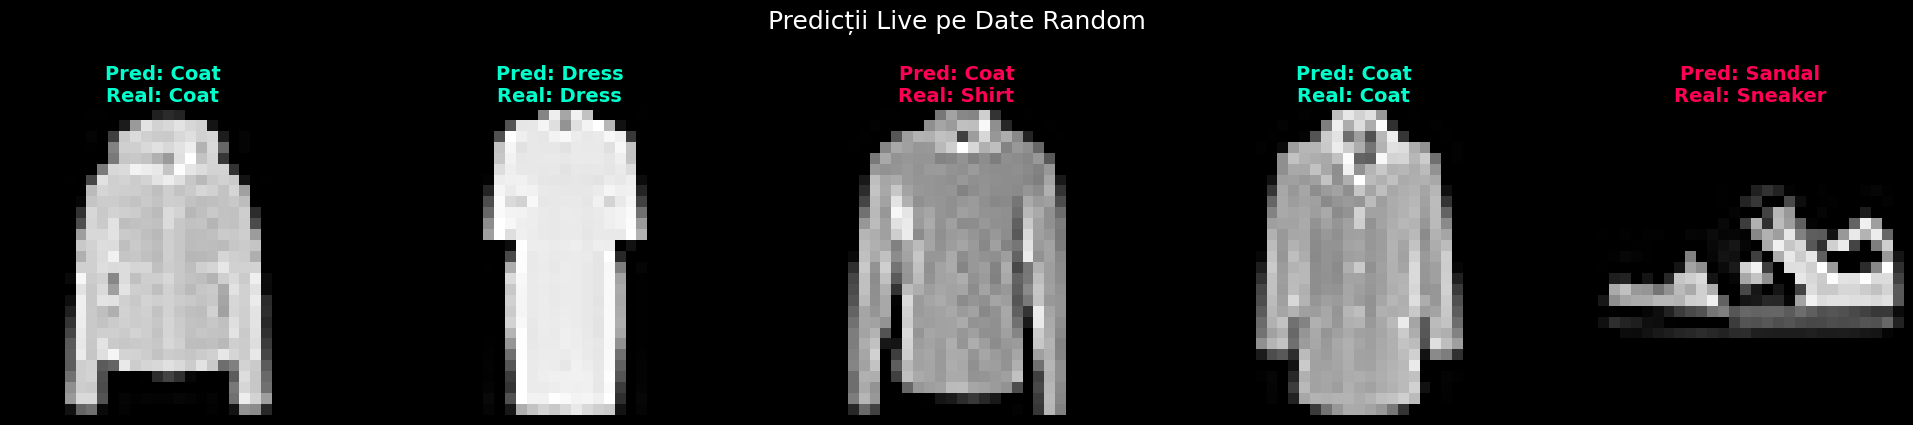

In [11]:
# 1. Încărcăm datele fresh și luăm clasa de nume
(_, _), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_test_norm = np.expand_dims(X_test.astype('float32') / 255.0, -1)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Alegem 5 imagini complet aleatorii
random_indices = np.random.choice(len(X_test), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Predicții Live pe Date Random', fontsize=18, color='white', y=1.05)

for i, idx in enumerate(random_indices):
    img = X_test_norm[idx]
    true_label = class_names[y_test[idx]]

    # Facem predicția folosind creierul AI
    prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label = class_names[np.argmax(prediction)]

    color = '#00ffcc' if true_label == pred_label else '#ff0055'

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Pred: {pred_label}\nReal: {true_label}", color=color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🏁 5. Concluzii Executive
Acest proiect demonstrează trecerea de la scrierea de scripturi izolate la **Inginerie de Software pentru Machine Learning (MLOps)**.

1. **Modularitate:** Împărțirea codului în Extragere (`01`), Antrenare (`02`) și Evaluare (`03`) asigură scalabilitatea proiectului într-un mediu de producție real.
2. **Eficiența Arhitecturii:** Înlocuirea straturilor clasice `Dense` cu `GlobalAveragePooling2D` a redus masiv parametrii inutili, prevenind Overfitting-ul.
3. **Încredere (Trust in AI):** Analiza vizuală dovedește că modelul a învățat să extragă logic marginile, gulerul, sau textura articolelor, nu doar să memoreze tipare aleatoare de pixeli.

> *Acest pipeline este gata pentru a fi implementat (Deployed) într-un API web sau pe dispozitive Edge.*